In [1]:
# Step - 1: Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Step - 2: Load the engineered IoT weather dataset
df = pd.read_csv('../data/engineered_iot_weather_dataset.csv')

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (9996, 40)
Columns: ['UDI', 'Product ID', 'Type', 'date', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Air temperature [K]_roll_mean', 'Air temperature [K]_roll_std', 'Air temperature [K]_roll_var', 'Process temperature [K]_roll_mean', 'Process temperature [K]_roll_std', 'Process temperature [K]_roll_var', 'Rotational speed [rpm]_roll_mean', 'Rotational speed [rpm]_roll_std', 'Rotational speed [rpm]_roll_var', 'Torque [Nm]_roll_mean', 'Torque [Nm]_roll_std', 'Torque [Nm]_roll_var', 'Tool wear [min]_roll_mean', 'Tool wear [min]_roll_std', 'Tool wear [min]_roll_var', 'avg_temp_c_roll_mean', 'avg_temp_c_roll_std', 'avg_temp_c_roll_var', 'min_temp_c_roll_mean', 'min_temp_c_roll_std', 'min_temp_c_roll_var', 'max_temp_c_roll_mean', 'max_temp_c_roll_std', 'max_temp_c_roll_var', 'precipitation_mm_roll_mean', 'precipitation_mm_roll_std', 'precipitation_mm_roll_var', 'avg_sea_level_pres_hpa_roll_mean', 'avg_sea_level_pres_hpa_roll_std', 'avg_sea_level_pres_hpa_roll_var']


,UDI,Product ID,Type,date,Machine failure,TWF,HDF,PWF,OSF,RNF,...,min_temp_c_roll_var,max_temp_c_roll_mean,max_temp_c_roll_std,max_temp_c_roll_var,precipitation_mm_roll_mean,precipitation_mm_roll_std,precipitation_mm_roll_var,avg_sea_level_pres_hpa_roll_mean,avg_sea_level_pres_hpa_roll_std,avg_sea_level_pres_hpa_roll_var
0,5,L47184,L,2020-01-01,0,0,0,0,0,0,...,0.0,30.3,0.0,0.0,27.9,0.0,0.0,1014.4,0.0,0.0
1,6,M14865,M,2020-01-01,0,0,0,0,0,0,...,0.0,30.3,0.0,0.0,27.9,0.0,0.0,1014.4,0.0,0.0
2,7,L47186,L,2020-01-01,0,0,0,0,0,0,...,0.0,30.3,0.0,0.0,27.9,0.0,0.0,1014.4,0.0,0.0
3,8,L47187,L,2020-01-01,0,0,0,0,0,0,...,0.0,30.3,0.0,0.0,27.9,0.0,0.0,1014.4,0.0,0.0
4,9,M14868,M,2020-01-01,0,0,0,0,0,0,...,0.0,30.3,0.0,0.0,27.9,0.0,0.0,1014.4,0.0,0.0


In [3]:
# Step 3: Understand dataset structure
# 9996 rows, 40 columns — IoT rolling features + weather rolling features
# Target: Machine failure (binary: 0 = normal, 1 = failure)

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total rows       : {df.shape[0]}")
print(f"Total columns    : {df.shape[1]}")
print(f"Failures (1)     : {df['Machine failure'].sum()}")
print(f"Normal (0)       : {(df['Machine failure']==0).sum()}")
print(f"Failure rate     : {df['Machine failure'].mean()*100:.2f}%")
print(f"Null values      : {df.isnull().sum().sum()}")
print("=" * 50)

DATASET OVERVIEW
Total rows       : 9996
Total columns    : 40
Failures (1)     : 339
Normal (0)       : 9657
Failure rate     : 3.39%
Null values      : 0


In [4]:
# Step 4: Analyze individual failure types
# TWF=Tool Wear, HDF=Heat Dissipation, PWF=Power,
# OSF=Overstrain, RNF=Random

failure_flags = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

print("=" * 50)
print("FAILURE TYPE BREAKDOWN")
print("=" * 50)
for flag in failure_flags:
    count = df[flag].sum()
    pct = count / len(df) * 100
    print(f"{flag}: {count} cases ({pct:.2f}%)")
print("=" * 50)
print(f"Total failures   : {df['Machine failure'].sum()}")

FAILURE TYPE BREAKDOWN
TWF: 46 cases (0.46%)
HDF: 115 cases (1.15%)
PWF: 95 cases (0.95%)
OSF: 98 cases (0.98%)
RNF: 19 cases (0.19%)
Total failures   : 339


In [5]:
# Step 5: Select IoT rolling mean columns and weather rolling mean columns
# We use _roll_mean columns for correlation — they represent
# the smoothed trend, less noisy than raw std/var

iot_mean_cols = [
    'Air temperature [K]_roll_mean',
    'Process temperature [K]_roll_mean',
    'Rotational speed [rpm]_roll_mean',
    'Torque [Nm]_roll_mean',
    'Tool wear [min]_roll_mean'
]

weather_mean_cols = [
    'avg_temp_c_roll_mean',
    'min_temp_c_roll_mean',
    'max_temp_c_roll_mean',
    'precipitation_mm_roll_mean',
    'avg_sea_level_pres_hpa_roll_mean'
]

# Combine for correlation analysis
corr_cols = iot_mean_cols + weather_mean_cols + ['Machine failure']
print("Columns selected for correlation:", len(corr_cols))

Columns selected for correlation: 11


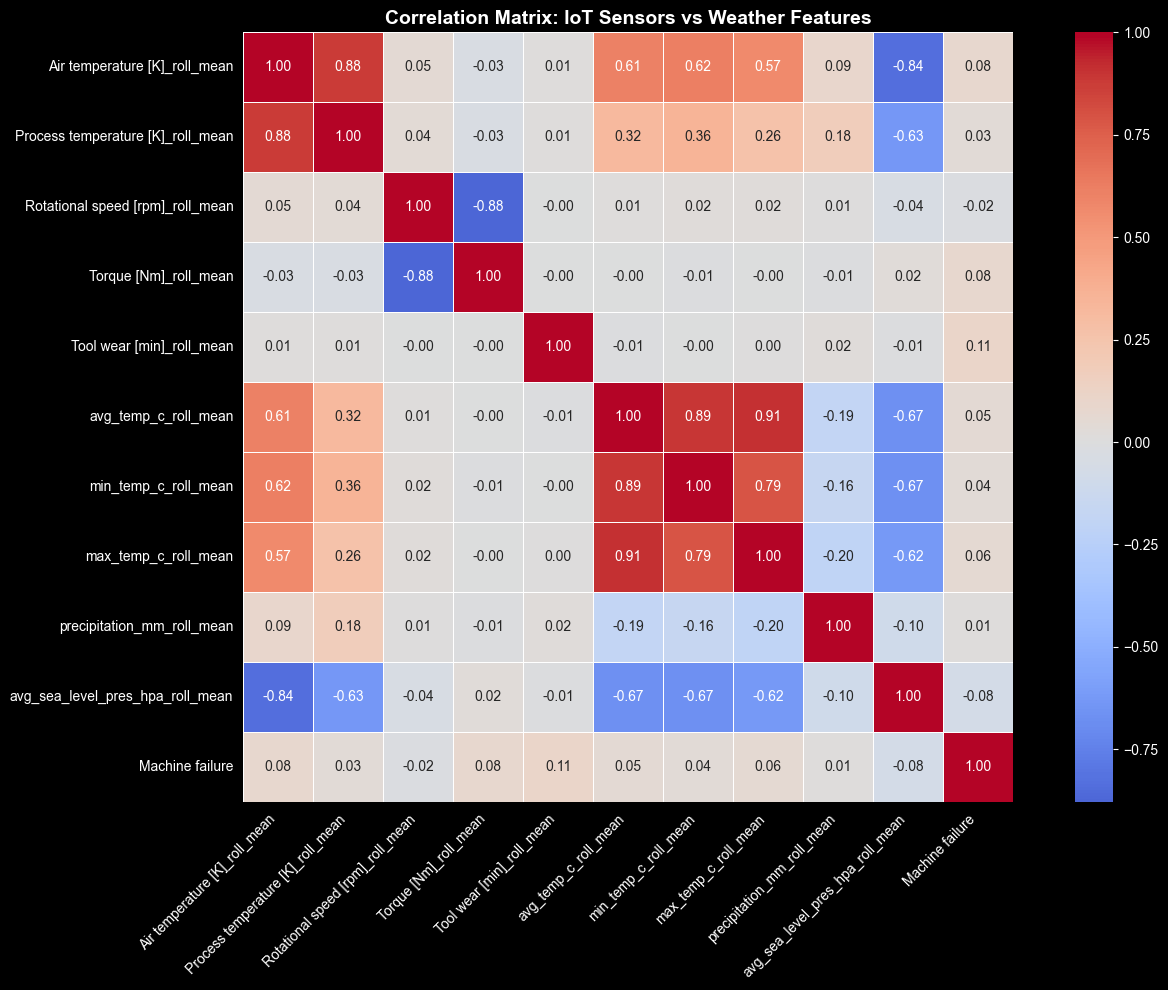

Saved to plots/correlation_heatmap_iot_weather.png


In [6]:
# Step 6: Generate correlation heatmap
# This shows relationships between IoT sensors, weather features,
# and machine failure — key insight for Track 2 EDA

plt.figure(figsize=(14, 10))
corr_matrix = df[corr_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix: IoT Sensors vs Weather Features',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../plots/correlation_heatmap_iot_weather.png', dpi=150)
plt.show()

print("Saved to plots/correlation_heatmap_iot_weather.png")